# 🌸 Iris Flower Classification using K-Nearest Neighbors (KNN) Algorithm from Scratch

<table>
<tr>
<td align="center">
<img src="https://upload.wikimedia.org/wikipedia/commons/a/a7/Irissetosa1.jpg" width="220"><br>
<b>Iris Setosa</b><br>
Class: 0
</td>

<td align="center">
<img src="https://upload.wikimedia.org/wikipedia/commons/4/41/Iris_versicolor_3.jpg" width="220"><br>
<b>Iris Versicolor</b><br>
Class: 1
</td>

<td align="center">
<img src="https://upload.wikimedia.org/wikipedia/commons/9/9f/Iris_virginica.jpg" width="220"><br>
<b>Iris Virginica</b><br>
Class: 2
</td>
</tr>
</table>

### **Machine Learning Project**

**Course:** Machine Learning Laboratory  
**Algorithm:** K-Nearest Neighbors (KNN)  
**Dataset:** Iris Dataset  
**Language:** Python

</div>

---

# 🎯 Objectives

- Understand the Iris dataset.
- Explore the dataset using Exploratory Data Analysis (EDA).
- Check the dataset for missing values.
- Analyze the statistical properties of the data.
- Split the dataset into training and testing sets.
- Implement the K-Nearest Neighbors algorithm from scratch.
- Predict the species of unseen flowers.
- Evaluate the performance of the model using accuracy.

---

# 🌼 About the Iris Dataset

The Iris dataset was introduced by the British statistician **Ronald A. Fisher** in 1936. It contains measurements of iris flowers belonging to three different species.

The dataset consists of **150 samples**, equally divided among three classes.

| Species | Encoded Label | Number of Samples |
|----------|---------------|-------------------|
| Iris Setosa | 0 | 50 |
| Iris Versicolor | 1 | 50 |
| Iris Virginica | 2 | 50 |

---



In [194]:
# Import Required Libraries

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score

In [195]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/Iris.csv")

# Display first five rows
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [196]:
# Unique Classes

print("Encoded Labels:", np.unique(y))

target_names = ["Iris-setosa", "Iris-versicolor", "Iris-virginica"]

print("\nClass Names:")
for i, name in enumerate(target_names):
    print(i, ":", name)

Encoded Labels: [0 1 2]

Class Names:
0 : Iris-setosa
1 : Iris-versicolor
2 : Iris-virginica


In [197]:
# Dataset Information

print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nTarget Classes:")
target_names = ["Iris-setosa", "Iris-versicolor", "Iris-virginica"]
print(target_names)

Shape of Dataset: (150, 6)

Column Names:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Target Classes:
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


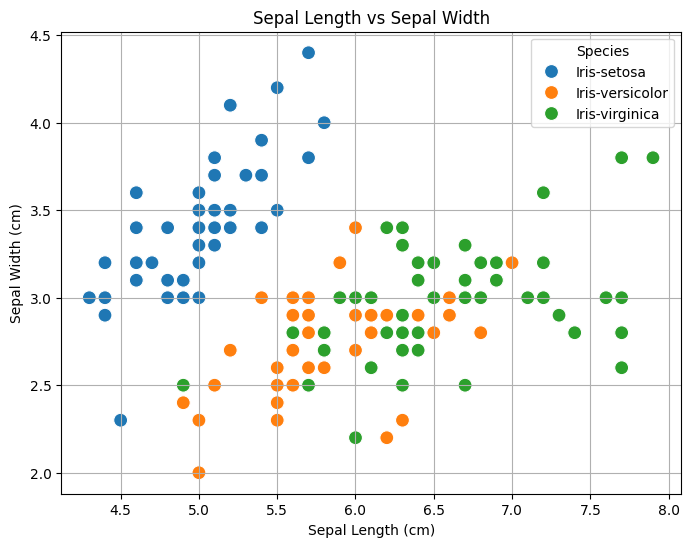

In [198]:
# Scatter Plot: Sepal Length vs Sepal Width

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="SepalLengthCm",
    y="SepalWidthCm",
    hue="Species",
    data=df,
    s=100
)

plt.title("Sepal Length vs Sepal Width")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.legend(title="Species")
plt.grid(True)

plt.show()

In [199]:
# Check Data Types and Missing Values

print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

Missing Values
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [200]:
# Statistical Summary

df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [201]:
# Number of Samples in Each Class

print(df["Species"].value_counts())

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [202]:
# Display 10 Random Samples

df.sample(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
72,73,6.3,2.5,4.9,1.5,Iris-versicolor
114,115,5.8,2.8,5.1,2.4,Iris-virginica
77,78,6.7,3.0,5.0,1.7,Iris-versicolor
50,51,7.0,3.2,4.7,1.4,Iris-versicolor
19,20,5.1,3.8,1.5,0.3,Iris-setosa
62,63,6.0,2.2,4.0,1.0,Iris-versicolor
18,19,5.7,3.8,1.7,0.3,Iris-setosa
102,103,7.1,3.0,5.9,2.1,Iris-virginica
125,126,7.2,3.2,6.0,1.8,Iris-virginica
85,86,6.0,3.4,4.5,1.6,Iris-versicolor


In [203]:
# Split Dataset

for rs in [0, 1, 5, 10, 25, 50]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.3,
        random_state=rs
    )

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 105
Testing Samples: 45


In [204]:
# Define KNN Class (From Scratch)

class KNN:

    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):

        predictions = []

        for test_point in X:

            distances = []

            for train_point in self.X_train:

                distance = np.sqrt(np.sum((train_point - test_point) ** 2))
                distances.append(distance)

            nearest = np.argsort(distances)[:self.k]

            labels = self.y_train[nearest]

            unique = np.unique(labels)

            best_label = None
            max_count = 0

            for label in unique:

                count = np.sum(labels == label)

                if count > max_count:
                    max_count = count
                    best_label = label

            predictions.append(best_label)

        return np.array(predictions)

In [205]:
# Train the Model

model = KNN(k=3)

model.fit(X_train, y_train)

In [206]:
# Make Predictions

y_pred = model.predict(X_test)

print("Actual Labels")
print(y_test)

print("\nPredicted Labels")
print(y_pred)

Actual Labels
[1 1 0 0 2 2 2 0 0 1 0 2 0 2 1 0 1 0 1 1 2 1 0 2 1 2 1 1 1 2 2 1 1 2 0 0 1
 2 1 0 0 1 2 0 2]

Predicted Labels
[1 2 0 0 2 2 2 0 0 2 0 2 0 2 1 0 1 0 1 1 2 1 0 2 1 2 1 1 1 2 2 1 1 2 0 0 1
 2 1 0 0 1 2 0 2]


In [207]:
# Compare Actual vs Predicted

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison

,Actual,Predicted
0,1,1
1,1,2
2,0,0
3,0,0
4,2,2
5,2,2
6,2,2
7,0,0
8,0,0
9,1,2


In [208]:
# Calculate Accuracy

correct = np.sum(y_pred == y_test)
total = len(y_test)

accuracy = correct / total

print("Correct Predictions:", correct)
print("Wrong Predictions:", total - correct)
print("Accuracy:", accuracy)

Correct Predictions: 43
Wrong Predictions: 2
Accuracy: 0.9555555555555556


In [209]:
# Predict a New Sample

species_names = sorted(df["Species"].unique())
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])

prediction = model.predict(new_sample)

print("Predicted Class:", prediction[0])
print("Flower Name:", species_names[prediction[0]])

Predicted Class: 0
Flower Name: Iris-setosa


In [210]:
# Minimum and Maximum Values

print("Minimum Values")
print(df.min(numeric_only=True))

print("\nMaximum Values")
print(df.max(numeric_only=True))

Minimum Values
Id               1.0
SepalLengthCm    4.3
SepalWidthCm     2.0
PetalLengthCm    1.0
PetalWidthCm     0.1
dtype: float64

Maximum Values
Id               150.0
SepalLengthCm      7.9
SepalWidthCm       4.4
PetalLengthCm      6.9
PetalWidthCm       2.5
dtype: float64


In [211]:
# Mean of Each Feature

print(df.iloc[:, :-1].mean())

Id               75.500000
SepalLengthCm     5.843333
SepalWidthCm      3.054000
PetalLengthCm     3.758667
PetalWidthCm      1.198667
dtype: float64


In [212]:
# Standard Deviation

print(df.iloc[:, :-1].std())

Id               43.445368
SepalLengthCm     0.828066
SepalWidthCm      0.433594
PetalLengthCm     1.764420
PetalWidthCm      0.763161
dtype: float64


In [213]:
# Accuracy Evaluation

correct = np.sum(y_pred == y_test)
accuracy = (correct / len(y_test)) * 100

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 95.56%


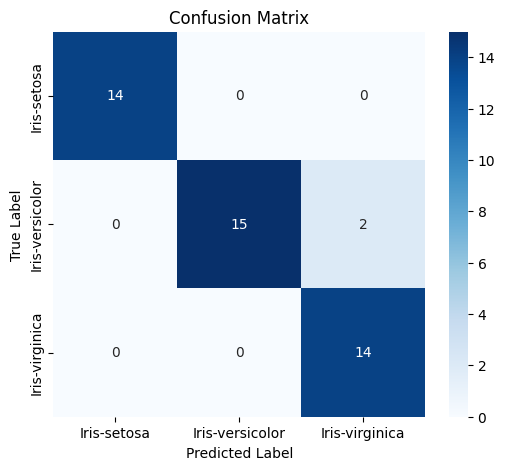

In [214]:
# Confusion Matrix Visualization

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=species_names,
    yticklabels=species_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

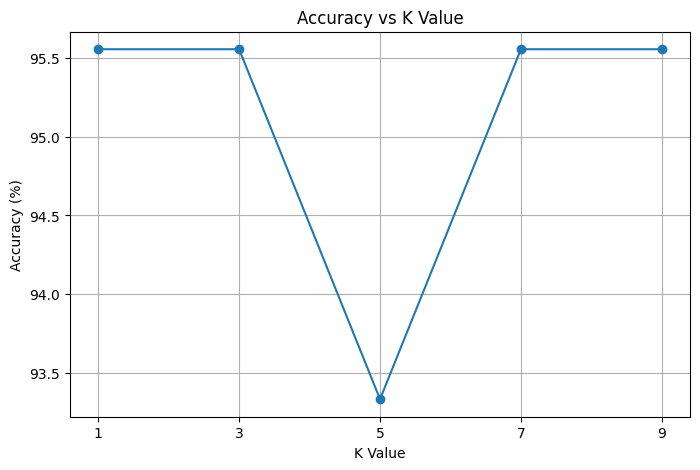

In [216]:
# Accuracy Comparison for Different K Values

k_values = []
accuracies = []

for k in range(1, 11,2):

    model = KNN(k=k)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred) * 100

    k_values.append(k)
    accuracies.append(acc)

plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o')
plt.title("Accuracy vs K Value")
plt.xlabel("K Value")
plt.ylabel("Accuracy (%)")
plt.xticks(k_values)
plt.grid(True)
plt.show()